### Problem1

In [2]:
import numpy as np
import numpy.random as nr
import matplotlib.pyplot as plt
from scipy.stats.qmc import PoissonDisk
from scipy import ndimage
from numpy.fft import fft, fftfreq, ifft
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"device: {device}")


device: cpu


In [3]:
h = 0.4 # Å, pixel size
N = 128 # pixel, system size
L = N*h # Å, sistem size
d = 2 # Å, minimum interatomic distance

print(f"system size = {L} Å")

system size = 51.2 Å


In [4]:
class imageGenerator:
    def __init__(self):
        self.h = 0.4 # Å, pixel size
        self.N = 128 # pixel, system size
        self.L = self.N*self.h # Å, sistem size
        self.d = 2 # Å, minimum interatomic distance

        x = np.arange(0, self.L, self.h)
        y = np.arange(0, self.L, self.h)
        self.X, self.Y = np.meshgrid(x, y)
        c = self.L/2 # center
        self.limitCircle = ((self.X-c)**2 + (self.Y-c)**2) < 20**2 # circlular limit


    def amorphous(self, minArea=5000, maxArea=11000, maskReturn=False):
        mask = np.zeros((self.N, self.N), dtype=float)
        go = True

        while go:
            x0 = nr.rand()*self.L
            y0 = nr.rand()*self.L
            r = nr.rand()*(10-5) + 5
            circle = ((self.X-x0)**2 + (self.Y-y0)**2 ) < r**2

            ix0 = np.clip(int(x0/self.h), 0, self.N-1)
            iy0 = np.clip(int(y0/self.h), 0, self.N-1)

            if np.any(circle & (~self.limitCircle)):
                continue
            
            elif (np.sum(mask) > 0) and mask[iy0, ix0] == False:
                continue

            else:
                mask += circle
                mask = np.clip(mask, 0, 1)

            area = np.sum(mask)

            if area > minArea:
                if np.random.uniform() > 0.5:
                    go = False
                elif area > maxArea:
                    go = False     
                    
        rng = np.random.default_rng()
        engine = PoissonDisk(d=2, radius=self.d/self.L, rng=rng)
        sample = engine.random(500)*self.L

        ix = np.clip((sample[:, 0]/self.h).astype(int), 0, self.N-1)
        iy = np.clip((sample[:, 1]/self.h).astype(int), 0, self.N-1)
        inside = mask[iy, ix] > 0
        self.sample = sample[inside]

        if maskReturn:
            return mask


    def makeImage(self):
        field = np.zeros_like(self.X)

        for i in range(len(self.sample)):
            xi = self.sample[i, 0]
            yi = self.sample[i, 1]
            field += np.exp(-((self.X - xi)**2 + (self.Y - yi)**2)/(2*0.45*0.45))

        return field

system size in pixel = (128, 128)
area of mask = 5254.0
number of atoms = (125, 2)
sampled density = [0.0237914]
target density = 0.05092958178940651


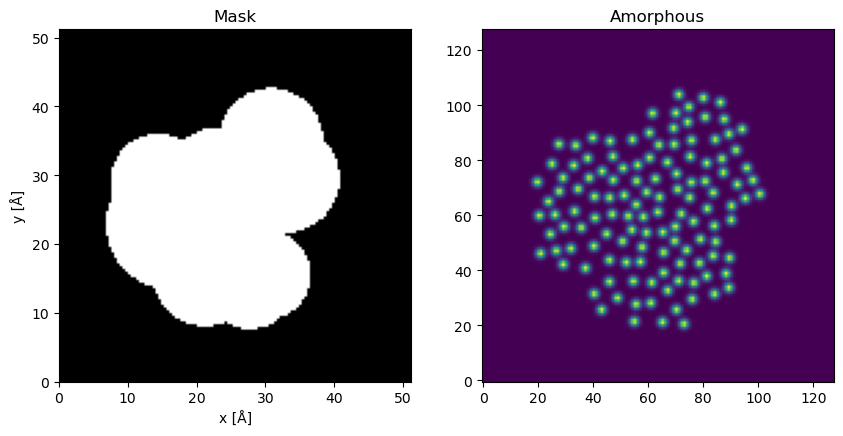

In [5]:
im = imageGenerator()
mask = im.amorphous(maskReturn=True)
img = im.makeImage()

print(f"system size in pixel = {np.shape(mask)}")
print(f"area of mask = {np.sum(mask)}")
print(f"number of atoms = {np.shape(im.sample)}")
print(f"sampled density = {np.shape(im.sample[:, 0])/np.sum(mask)}")
print(f"target density = {1/(np.pi*2.5*2.5)}")

fig = plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.imshow(mask, origin="lower", extent=[0, L, 0, L], cmap='binary_r')
#plt.scatter(im.sample[:, 0], im.sample[:, 1])
plt.xlabel('x [Å]')
plt.ylabel('y [Å]')
plt.title('Mask')

plt.subplot(122)
plt.imshow(img, origin="lower")
plt.title("Amorphous")

plt.show()


### Problem2

In [6]:
def Radon(image, angles):
    sinogram = np.zeros((image.shape[0], len(angles)), dtype=float)

    for i in range(len(angles)):
        sinogram[:, i] = np.sum(ndimage.rotate(image, angles[i], reshape=False), axis=0)

    return sinogram


def inverseRadon(sinogram, angles):
    N = sinogram.shape[0]
    F = fft(sinogram, axis=0)
    angles = angles*np.pi/180

    freq = fftfreq(N)
    ramp = np.abs(freq)
    F_filtered = F*ramp[:, None]

    filtered = ifft(F_filtered, axis=0).real

    reconstruction = np.zeros((N, N))

    c = N//2 # center
    x = np.arange(N) - c
    y = np.arange(N) - c

    X, Y = np.meshgrid(x, y)

    for i, angle in enumerate(angles):
        t = X*np.cos(angle) + Y*np.sin(angle)

        proj = filtered[:, i]
        proj_axis = np.arange(N) - c

        backproj = np.interp(t, proj_axis, proj, left=0, right=0)

        reconstruction += backproj

    return reconstruction*np.pi/len(angles)

In [7]:
import scipy as sp

def iradon_transform(Sinogram, AngleArr, interpolation='linear'):
    Dim = Sinogram.shape[0]
    #radon_image = sinogram_circle_to_square(radon_image)
    AngleArr_rad = (np.pi / 180.0) * AngleArr
    
    # resize image to next power of two (but no less than 64) for
    # Fourier analysis; speeds up Fourier and lessens artifacts
    projection_size_padded = max(64, int(2 ** np.ceil(np.log2(2 * Sinogram.shape[0]))))
    pad_width = ((0, projection_size_padded - Sinogram.shape[0]), (0, 0))
    PaddedSinogram = np.pad(Sinogram, pad_width, mode='constant', constant_values=0)
    
    f = np.fft.fftfreq(projection_size_padded).reshape(-1, 1)   # digital frequency
    omega = 2 * np.pi * f                                # angular frequency
    fourier_filter = 2 * np.abs(f)                       # ramp filter
    Projection = np.fft.fft(PaddedSinogram, axis=0) * fourier_filter
    
    FilteredSinogram = np.real(np.fft.ifft(Projection, axis=0))
    FilteredSinogram = FilteredSinogram[:Sinogram.shape[0], :] # undo padding
    
    Reconstruction = np.zeros((Dim, Dim))
    Mid_index = Sinogram.shape[0] // 2
    [X, Y] = np.mgrid[0:Dim, 0:Dim]
    xpr = X - int(Dim) // 2
    ypr = Y - int(Dim) // 2
    
    # Reconstruct image by adding interpolated backprojections
    interpolation_types = ('linear', 'nearest', 'cubic')
    
    if interpolation not in interpolation_types:
        raise ValueError("Unknown interpolation: %s" % interpolation)
        
    for i in range(len(AngleArr_rad)):
        t = + ypr * np.cos(AngleArr_rad[i]) + xpr * np.sin(AngleArr_rad[i])
        x = np.arange(FilteredSinogram.shape[0]) - Mid_index
        if interpolation == 'linear':
            Backprojected = np.interp(t, x, FilteredSinogram[:, i],
                                      left=0, right=0)
        else:
            interpolant = sp.interpolate.interp1d(x, FilteredSinogram[:, i], kind=interpolation,
                                   bounds_error=False, fill_value=0)
            Backprojected = interpolant(t)
            
        Reconstruction += Backprojected
    Rad = Dim // 2
    Rec_circle = (xpr ** 2 + ypr ** 2) <= Rad ** 2
    Reconstruction[~Rec_circle] = 0.

    return Reconstruction * np.pi / (2 * len(AngleArr_rad))


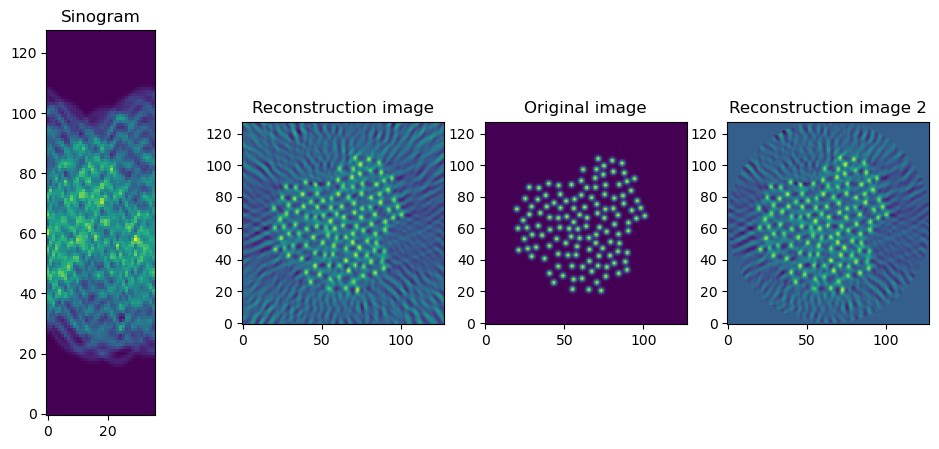

In [8]:
angles= np.arange(-70.0, 70.0 + 4, 4)
Sinogram = Radon(img, angles)
reconstruct = inverseRadon(Sinogram, angles)
reconstruct2 = iradon_transform(Sinogram, angles)


fig = plt.figure(figsize=(12, 5))

plt.subplot(141)
plt.imshow(Sinogram, origin="lower")
plt.title('Sinogram')

plt.subplot(142)
plt.imshow(reconstruct, origin="lower")
plt.title("Reconstruction image")

plt.subplot(143)
plt.imshow(img, origin="lower")
plt.title("Original image")

plt.subplot(144)
plt.imshow(reconstruct2, origin="lower")
plt.title("Reconstruction image 2")

plt.show()

### Problem 3

In [ ]:
N_training = 1000 # Number of images for training

imgs_bf_np = np.zeros((N_training, 1, 128, 128), dtype=np.float32) # Images before tomography reconstruction
imgs_af_np = np.zeros((N_training, 1, 128, 128), dtype=np.float32) # Images after tomography reconstruction

im = imageGenerator()
angles= np.arange(-70.0, 70.0 + 4, 4)

for i in tqdm(range(N_training)):
    im.amorphous()
    imgs_bf_np[i, 0, :, :] = im.makeImage()
    sinogram = Radon(imgs_bf_np[i, 0, :, :], angles)
    imgs_af_np[i, 0, :, :] = inverseRadon(sinogram, angles)


fig = plt.figure(figsize=(12, 5))
i = 0

plt.subplot(121)
plt.imshow(imgs_bf_np[i], origin="lower")
plt.title('Sinogram')

plt.subplot(122)
plt.imshow(imgs_af_np[i], origin="lower")
plt.title("Reconstruction image")

plt.show()

In [ ]:
class tomographyDataset(Dataset):
    def __init__(self, img_before, img_after):
        self.img_before = img_before
        self.img_after = img_after

    
    def __len__(self):
        return len(self.img_before)
    

    def __getitem__(self, idx):
        return self.img_before[idx], self.img_after[idx]